# EDA Pingüinos Palmer

El conjunto de datos Palmer Penguins contiene información sobre 344 pingüinos pertenecientes a tres especies diferentes que habitan en el Archipiélago Palmer, en la Antártida. Este dataset incluye diversas medidas morfológicas de los ejemplares, tales como la longitud y profundidad del pico, la longitud de las aletas y la masa corporal. Además, incorpora información complementaria como el sexo, el año de registro y la isla donde fue observado cada individuo.

Hay tres especies de pingüinos en el conjunto de datos: Adelie, Gentoo, y Chinstrap. Conocidos cientificamente como Pygoscelis adeliae, Pygoscelis papua, y Pygoscelis antarctica, respectivamente. Cada especie se identifica en el dataset por su nombre común.


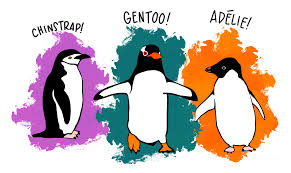

### OBJETIVO

El objetivo de este análisis exploratorio es comprender la estructura y las características del conjunto de datos Palmer Penguins, identificando patrones, tendencias y posibles relaciones entre las variables del dataset. Asimismo, detectar valores atípicos, tratar datos faltantes y la preparación de los datos para los modelos predictivos posteriores.

In [10]:
#Librerías necesarias
import numpy as np #Cálculos
import pandas as pd #Dataframes
import seaborn as sns #Gráficos
import matplotlib.pyplot as plt #Gráficos

In [2]:
#Instalar librería de los pingüinos
!pip install palmerpenguins

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [12]:
#Inspección a los datos
from palmerpenguins import load_penguins

pinwinos = load_penguins()
pinwinos.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


In [13]:
#Estructura de base de datos
print(pinwinos.shape)

(344, 8)


In [14]:
#Renombrando nombres de columnas a español
pinwinos = pinwinos.rename(columns={
    "species": "Especie",
    "island": "Isla",
    "bill_length_mm": "Longitud_Pico_mm",
    "bill_depth_mm": "Profundidad_Pico_mm",
    "flipper_length_mm": "Longitud_Aleta_mm",
    "body_mass_g": "Masa_Corporal_g",
    "sex": "Sexo",
    "year": "Anio"
})

pinwinos["Sexo"] = pinwinos["Sexo"].replace({"female": "Hembra", "male": "Macho"})

In [15]:
#Conversiones a unidades de cm y kg
pinwinos["Longitud_Pico_cm"] = pinwinos["Longitud_Pico_mm"]/10
pinwinos["Profundidad_Pico_cm"] = pinwinos["Profundidad_Pico_mm"]/10
pinwinos["Longitud_Aleta_cm"] = pinwinos["Longitud_Aleta_mm"]/10
pinwinos["Masa_Corporal_kg"] = pinwinos["Masa_Corporal_g"]/1000

#Eliminamos columnas pasadas
pinwinos = pinwinos.drop(columns=["Longitud_Pico_mm"])
pinwinos = pinwinos.drop(columns=["Profundidad_Pico_mm"])
pinwinos = pinwinos.drop(columns=["Longitud_Aleta_mm"])
pinwinos = pinwinos.drop(columns=["Masa_Corporal_g"])

In [16]:
#Nuevamente inspección a los datos
pinwinos.head()

,Especie,Isla,Sexo,Anio,Longitud_Pico_cm,Profundidad_Pico_cm,Longitud_Aleta_cm,Masa_Corporal_kg
0,Adelie,Torgersen,Macho,2007,3.91,1.87,18.1,3.75
1,Adelie,Torgersen,Hembra,2007,3.95,1.74,18.6,3.80
2,Adelie,Torgersen,Hembra,2007,4.03,1.80,19.5,3.25
3,Adelie,Torgersen,NaN,2007,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,Hembra,2007,3.67,1.93,19.3,3.45


## Glosario de variables:

1.   **Especie** -	Especie del pingüino: Adelie, Chinstrap o Gentoo.
2.   **Isla** -	Isla del archipiélago Palmer donde fue observado el pingüino.
3.   **Sexo** -	Sexo biológico del individuo (macho o hembra).
4.   **Anio** - Año en que se realizó la observación o medición.
5.   **Longitud_Pico_cm**	- Longitud del pico en centímetros.
6.   **Profundidad_Pico_cm** -	Profundidad o altura del pico en centímetros.
7.   **Longitud_Aleta_cm** - Longitud de la aleta en centímetros.
8.   **Masa_Corporal_kg** -	Masa corporal del pingüino en kilogramos.



In [51]:
#Cantidad de NA's en la base
print(pinwinos.isnull().sum())

Especie                0
Isla                   0
Sexo                   0
Anio                   0
Longitud_Pico_cm       0
Profundidad_Pico_cm    0
Longitud_Aleta_cm      0
Masa_Corporal_kg       0
dtype: int64


In [52]:
#Filas con NAs de las variables Longitud_Pico_cm, Profundidad_Pico_cm, Longitud_Aleta_cm  y Masa_Corporal_kg
print(
    pinwinos[
        pinwinos[['Longitud_Pico_cm',
            'Profundidad_Pico_cm',
            'Longitud_Aleta_cm',
            'Masa_Corporal_kg'
           ]].isna().any(axis=1)
    ][['Especie',
       'Longitud_Pico_cm',
       'Profundidad_Pico_cm',
       'Longitud_Aleta_cm',
       'Masa_Corporal_kg']]
)

Empty DataFrame
Columns: [Especie, Longitud_Pico_cm, Profundidad_Pico_cm, Longitud_Aleta_cm, Masa_Corporal_kg]
Index: []


Como observamos anteriormente, estos dos filas son de especie Adelie y Gentoo respectivamente. Ya que las características morfológicas varían entre especies, tomaremos el **promedio** de cada variable dentro de la especie corrrespondiente.


In [53]:
#Promedios de columnas de especia Adelie
mediaPicoadelie = round(pinwinos.loc[pinwinos["Especie"] == "Adelie", "Longitud_Pico_cm"].mean(),2)
mediaProfpicoadelie = round(pinwinos.loc[pinwinos["Especie"] == "Adelie", "Profundidad_Pico_cm"].mean(),2)
mediaAletaadelie = round(pinwinos.loc[pinwinos["Especie"] == "Adelie", "Longitud_Aleta_cm"].mean(),2)
mediaPesoadelie = round(pinwinos.loc[pinwinos["Especie"] == "Adelie", "Masa_Corporal_kg"].mean(),2)

pinwinos.loc[pinwinos["Especie"] == "Adelie", "Longitud_Pico_cm"] = \
    pinwinos.loc[pinwinos["Especie"] == "Adelie", "Longitud_Pico_cm"].fillna(mediaPicoadelie)

pinwinos.loc[pinwinos["Especie"] == "Adelie", "Profundidad_Pico_cm"] = \
    pinwinos.loc[pinwinos["Especie"] == "Adelie", "Profundidad_Pico_cm"].fillna(mediaProfpicoadelie)

pinwinos.loc[pinwinos["Especie"] == "Adelie", "Longitud_Aleta_cm"] = \
    pinwinos.loc[pinwinos["Especie"] == "Adelie", "Longitud_Aleta_cm"].fillna(mediaAletaadelie)

pinwinos.loc[pinwinos["Especie"] == "Adelie", "Masa_Corporal_kg"] = \
    pinwinos.loc[pinwinos["Especie"] == "Adelie", "Masa_Corporal_kg"].fillna(mediaPesoadelie)


#Promedios de columnas de especia Gentoo
mediaPicogentoo = round(pinwinos.loc[pinwinos["Especie"] == "Gentoo", "Longitud_Pico_cm"].mean(),2)
mediaProfpicogentoo = round(pinwinos.loc[pinwinos["Especie"] == "Gentoo", "Profundidad_Pico_cm"].mean(),2)
mediaAletagentoo = round(pinwinos.loc[pinwinos["Especie"] == "Gentoo", "Longitud_Aleta_cm"].mean(),2)
mediaPesogentoo = round(pinwinos.loc[pinwinos["Especie"] == "Gentoo", "Masa_Corporal_kg"].mean(),2)

pinwinos.loc[pinwinos["Especie"] == "Gentoo", "Longitud_Pico_cm"] = \
    pinwinos.loc[pinwinos["Especie"] == "Gentoo", "Longitud_Pico_cm"].fillna(mediaPicogentoo)

pinwinos.loc[pinwinos["Especie"] == "Gentoo", "Profundidad_Pico_cm"] = \
    pinwinos.loc[pinwinos["Especie"] == "Gentoo", "Profundidad_Pico_cm"].fillna(mediaProfpicogentoo)

pinwinos.loc[pinwinos["Especie"] == "Gentoo", "Longitud_Aleta_cm"] = \
    pinwinos.loc[pinwinos["Especie"] == "Gentoo", "Longitud_Aleta_cm"].fillna(mediaAletagentoo)

pinwinos.loc[pinwinos["Especie"] == "Gentoo", "Masa_Corporal_kg"] = \
    pinwinos.loc[pinwinos["Especie"] == "Gentoo", "Masa_Corporal_kg"].fillna(mediaPesogentoo)

Con el objetivo de clasificar los registros con **valores faltantes en la variable sexo**, realizamos un análisis de las características de los pingüinos.  A partir de este análisis, se determinaron los criterios más adecuados para asignar la mejor clasificación a cada individuo según sus características morfológicas.

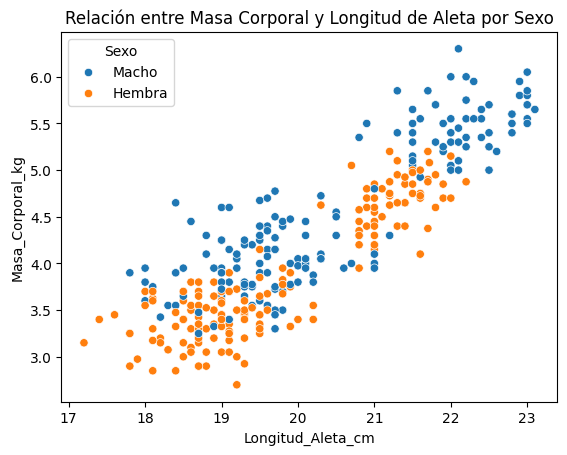

In [54]:
#Diagramas de dispersión con el objetivo de buscar una relación entre variables para la imputación de datos faltantes
sns.scatterplot(x="Longitud_Aleta_cm", y="Masa_Corporal_kg", hue="Sexo", data=pinwinos)
plt.title("Relación entre Masa Corporal y Longitud de Aleta por Sexo")
plt.show()

La separación por sexo no resulta concluyente, ya que la dispersión de los datos genera un alto nivel de ruido y dificulta establecer una división clara entre los grupos.

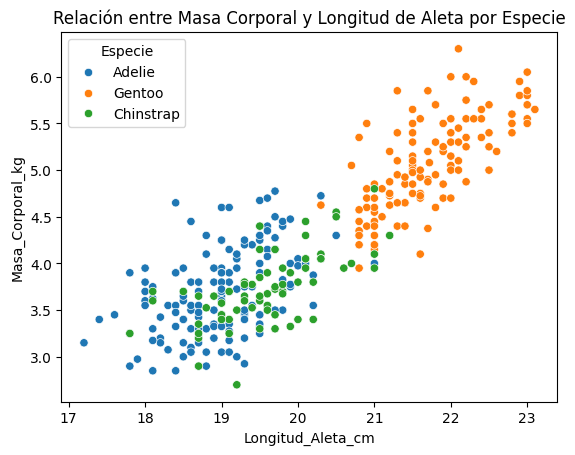

In [55]:
sns.scatterplot(
    x="Longitud_Aleta_cm",
    y="Masa_Corporal_kg",
    hue="Especie",
    data=pinwinos
)
plt.title("Relación entre Masa Corporal y Longitud de Aleta por Especie")
plt.show()

 Al clasificar por especie, se revelan patrones entre la masa corporal y longitud de aleta de los pingüinos, lo que facilita distinguir diferencias morfológicas entre grupos. No obstante, es necesario acercarnos más a cada especie para observar con mayor detalle cómo varía el sexo dentro de esos rangos definidos:

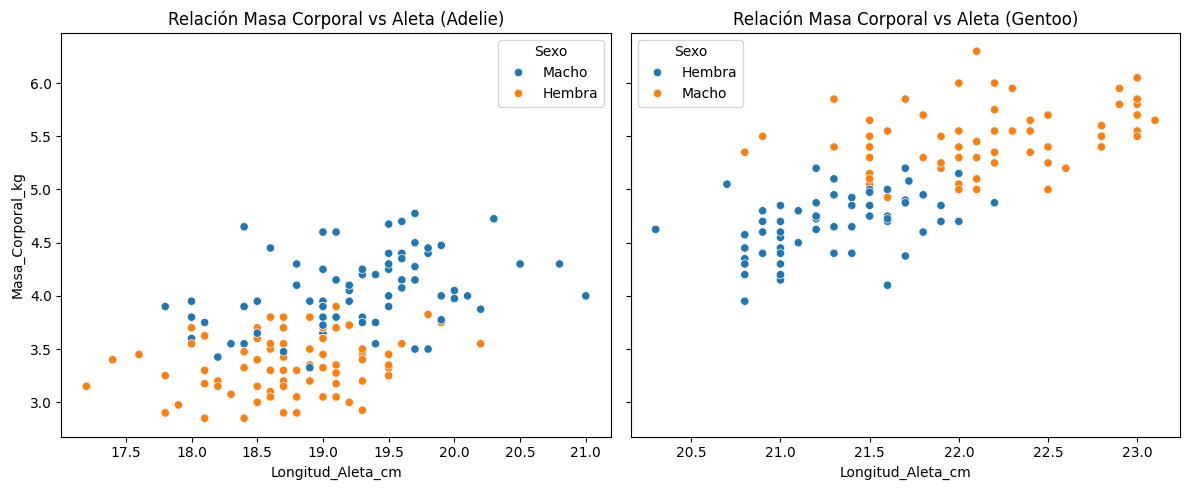

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

adelie = pinwinos[pinwinos["Especie"] == "Adelie"]
sns.scatterplot(
    x="Longitud_Aleta_cm",
    y="Masa_Corporal_kg",
    hue="Sexo",
    data=adelie,
    ax=axes[0]
)
axes[0].set_title("Relación Masa Corporal vs Aleta (Adelie)")

gentoo = pinwinos[pinwinos["Especie"] == "Gentoo"]
sns.scatterplot(
    x="Longitud_Aleta_cm",
    y="Masa_Corporal_kg",
    hue="Sexo",
    data=gentoo,
    ax=axes[1]
)
axes[1].set_title("Relación Masa Corporal vs Aleta (Gentoo)")

plt.tight_layout()
plt.show()

In [57]:
mediaPesoadeliemacho = round(pinwinos.loc[(pinwinos["Especie"] == "Adelie") & (pinwinos["Sexo"] == "Macho"),"Masa_Corporal_kg"].mean(), 2)
mediaPesogentoomacho = round(pinwinos.loc[(pinwinos["Especie"] == "Gentoo") & (pinwinos["Sexo"] == "Macho"), "Masa_Corporal_kg"].mean(),2)

print(mediaPesoadeliemacho)
print(mediaPesogentoomacho)

4.05
5.48


A partir de este gráfico,  podemos observar diferencias claras entre machos y hembras dentro de las especies de pingüinos. Por tanto, para imputar los 11 datos faltantes en la columna 'Sexo':

*   Haremos la clasificación para las especies 'Adelie' y 'Gentoo' con respecto al promedio de su masa corporal por especie y sexo. En la especie Adelie, los machos representan una masa corporal promedio de **4.04 kg**, mientras que en la especie Gentoo, los machos tienen una masa corporal promedio de **5.48 kg**. Ya con estos valores de referencia, los pingüinos con masa corporal inferior a dichos promedios los clasificamos como hembras, mientras aquellos con masa corporal superior los clasicamos como machos.

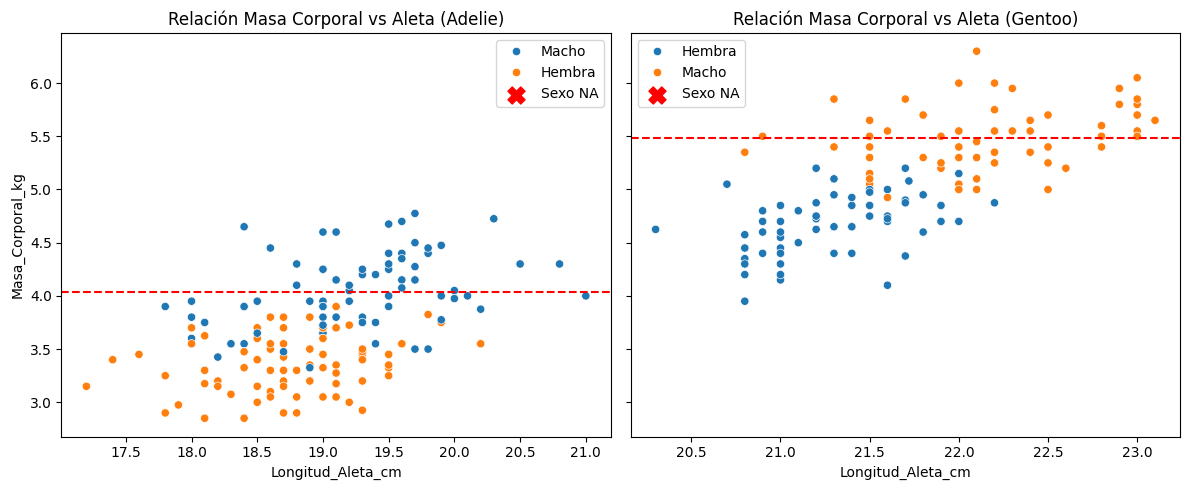

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# Adelie
adelie = pinwinos[pinwinos["Especie"] == "Adelie"]
sns.scatterplot(
    x="Longitud_Aleta_cm",
    y="Masa_Corporal_kg",
    hue="Sexo",
    data=adelie,
    ax=axes[0]
)
axes[0].axhline(y=4.04, color="red", linestyle="--")
# Puntos con sexo faltante
na_adelie = adelie[adelie['Sexo'].isna()]
axes[0].scatter(
    na_adelie['Longitud_Aleta_cm'],
    na_adelie['Masa_Corporal_kg'],
    color='red',
    s=150,
    marker='X',
    label='Sexo NA'
)
axes[0].set_title("Relación Masa Corporal vs Aleta (Adelie)")
axes[0].legend()

# Gentoo
gentoo = pinwinos[pinwinos["Especie"] == "Gentoo"]
sns.scatterplot(
    x="Longitud_Aleta_cm",
    y="Masa_Corporal_kg",
    hue="Sexo",
    data=gentoo,
    ax=axes[1]
)
axes[1].axhline(y=5.48, color="red", linestyle="--")
# Puntos con sexo faltante
na_gentoo = gentoo[gentoo['Sexo'].isna()]
axes[1].scatter(
    na_gentoo['Longitud_Aleta_cm'],
    na_gentoo['Masa_Corporal_kg'],
    color='red',
    s=150,
    marker='X',
    label='Sexo NA'
)
axes[1].set_title("Relación Masa Corporal vs Aleta (Gentoo)")
axes[1].legend()

plt.tight_layout()
plt.show()


In [59]:
# Hembra
pinwinos.loc[
    (
        ((pinwinos["Especie"] == "Adelie") & (pinwinos["Masa_Corporal_kg"] < 4.04)) |
        ((pinwinos["Especie"] == "Gentoo") & (pinwinos["Masa_Corporal_kg"] < 5.48))
    )
    & pinwinos["Sexo"].isna(),
    "Sexo"
] = "Hembra"

# Macho
pinwinos.loc[
    (
        ((pinwinos["Especie"] == "Adelie") & (pinwinos["Masa_Corporal_kg"] >= 4.04)) |
        ((pinwinos["Especie"] == "Gentoo") & (pinwinos["Masa_Corporal_kg"] >= 5.48))
    )
    & pinwinos["Sexo"].isna(),
    "Sexo"
] = "Macho"



In [60]:
#Cantidad de NA's en la base
print(pinwinos.isnull().sum())

Especie                0
Isla                   0
Sexo                   0
Anio                   0
Longitud_Pico_cm       0
Profundidad_Pico_cm    0
Longitud_Aleta_cm      0
Masa_Corporal_kg       0
dtype: int64


In [61]:
pinwinos.head()

,Especie,Isla,Sexo,Anio,Longitud_Pico_cm,Profundidad_Pico_cm,Longitud_Aleta_cm,Masa_Corporal_kg
0,Adelie,Torgersen,Macho,2007,3.91,1.87,18.1,3.75
1,Adelie,Torgersen,Hembra,2007,3.95,1.74,18.6,3.80
2,Adelie,Torgersen,Hembra,2007,4.03,1.80,19.5,3.25
3,Adelie,Torgersen,Hembra,2007,3.88,1.83,19.0,3.70
4,Adelie,Torgersen,Hembra,2007,3.67,1.93,19.3,3.45


Limpieza de base de datos completa.

In [62]:
pinwinos.to_csv("PinwinosPalmerLimpia.csv", index=False)

Una vez realizada la limpieza e imputación de los datos faltantes, continuamos al análisis descriptivo de las variables numéricas del conjunto de datos. A continuación, se presentan las principales medidas estadísticas como media, desviación estándar, valores mínimos, máximos y cuartiles, para las variables Longitud_Pico_cm, Profundidad_Pico_cm, Longitud_Aleta_cm y Masa_Corporal_kg.

In [63]:
variablesnum = pinwinos.drop(columns=["Anio"])
print(variablesnum.describe())

       Longitud_Pico_cm  Profundidad_Pico_cm  Longitud_Aleta_cm  \
count        344.000000           344.000000         344.000000   
mean           4.391744             1.714826          20.093081   
std            0.545408             0.197342           1.406055   
min            3.210000             1.310000          17.200000   
25%            3.920000             1.557500          19.000000   
50%            4.445000             1.730000          19.700000   
75%            4.850000             1.870000          21.325000   
max            5.960000             2.150000          23.100000   

       Masa_Corporal_kg  
count        344.000000  
mean           4.202849  
std            0.801475  
min            2.700000  
25%            3.550000  
50%            4.050000  
75%            4.756250  
max            6.300000  


*    Longitud del Pico (cm)
Media de 4.39 cm con poca dispersión (std 0.54). Su rango va de 3.21 a 5.96 cm y no presenta valores atípicos problemáticos. Sugiere que los pingüinos son bastante similares en esta medida, aunque puede ayudar a distinguir especies.

*    Profundidad del Pico (cm)
Media de 1.71 cm con muy poca dispersión (std 0.20), la más homogénea de las cuatro. Su rango va de 1.31 a 2.15 cm y no presenta valores atípicos problemáticos. Sugiere que la profundidad varía poco entre individuos, pero sí distingue entre especies.

*    Longitud de Aleta (cm)
Media de 20.09 cm con dispersión moderada (std 1.41). Su rango va de 17.2 a 23.1 cm y no presenta valores atípicos problemáticos. Sugiere que hay diferencias reales entre especies, siendo esta probablemente una de las variables más útiles para clasificarlas.

*    Masa Corporal (kg)
Media de 4.20 kg con la mayor dispersión del grupo (std 0.80). Su rango va de 2.7 a 6.3 kg y no presenta valores atípicos problemáticos. Sugiere que el peso varía bastante entre individuos, lo que lo convierte en una variable clave tanto para identificar la especie como el sexo.


Conteo de variables categóricas:
Anio
2009    120
2008    114
2007    110
Name: count, dtype: int64
Especie
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64
Isla
Biscoe       168
Dream        124
Torgersen     52
Name: count, dtype: int64
Sexo
Hembra    175
Macho     169
Name: count, dtype: int64


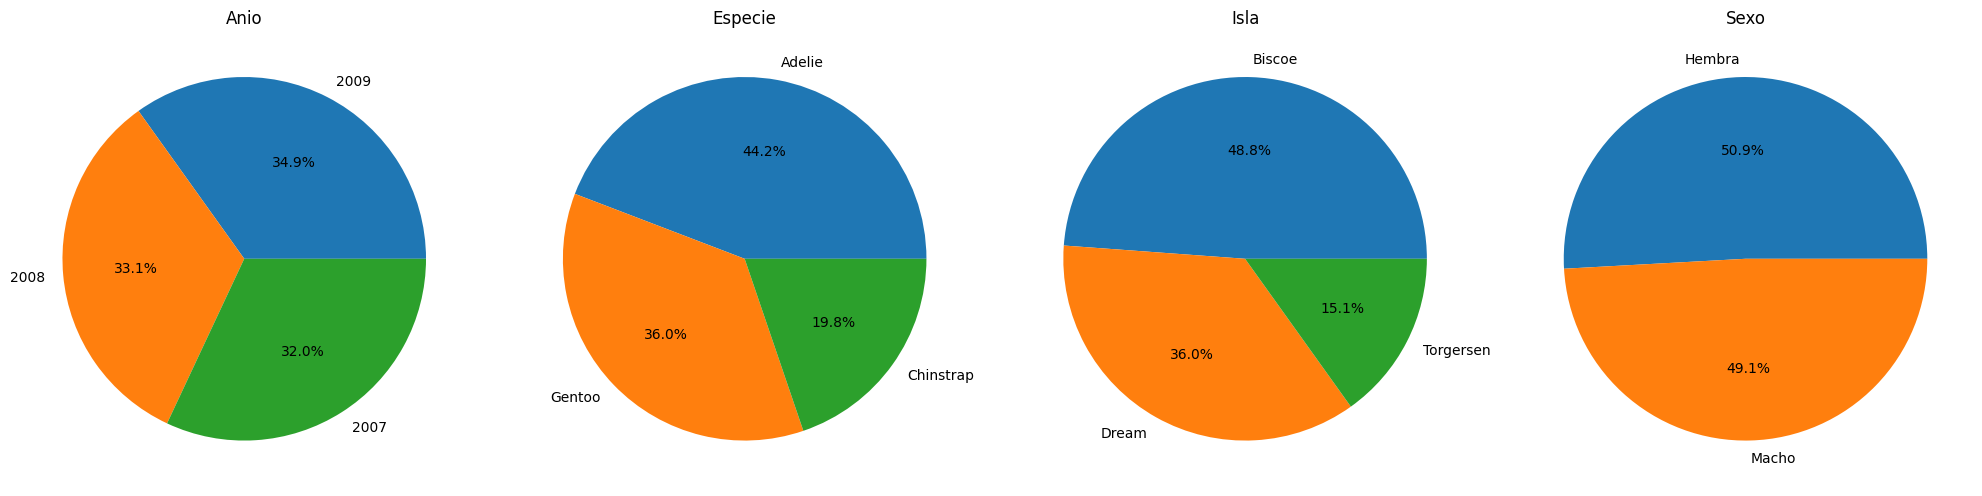

In [64]:
#Conteo de variables categóricas
print("\nConteo de variables categóricas:")
print(pinwinos['Anio'].value_counts())
print(pinwinos['Especie'].value_counts())
print(pinwinos['Isla'].value_counts())
print(pinwinos['Sexo'].value_counts())

#Gráfico de concentración de tipo de respuesta
variables = ['Anio', 'Especie', 'Isla', 'Sexo']

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for ax, var in zip(axes, variables):
    pinwinos[var].value_counts().plot(
        kind='pie',
        autopct='%1.1f%%',
        ax=ax
    )
    ax.set_title(f'{var}')
    ax.set_ylabel('')

plt.tight_layout()
plt.show()

De las variables categóricas:

*   Año: la base de datos fue muy constante en los tres años observados
*   Especie: existen más observaciones de los pingüinos Adelie por lo que los análisis serán más influenciados por ellos.
*   Isla: los datos están algo sesgados hacia la isla Biscoe
*   Sexo: un balance casi perfecto

La base de datos presenta un desbalance moderado entre especies, Adelie representa el 44.2% de los registros, mientras que Chinstrap apenas alcanza el 19.8%, lo que hace que la evaluación **accuracy** sola sea una métrica insuficiente, ya que un modelo que ignore Chinstrap podría reportar números altos simplemente por predecir siempre la clase mayoritaria. Por esta razón se establecerá un baseline con la regla del mayoritario como piso mínimo a superar, se adoptará el **F1-macro** como métrica principal de evaluación al ponderar igual las tres clases,y se usará **validación cruzada** en 5 particiones para garantizar que las tres especies estén representadas proporcionalmente en cada división del conjunto de entrenamiento.



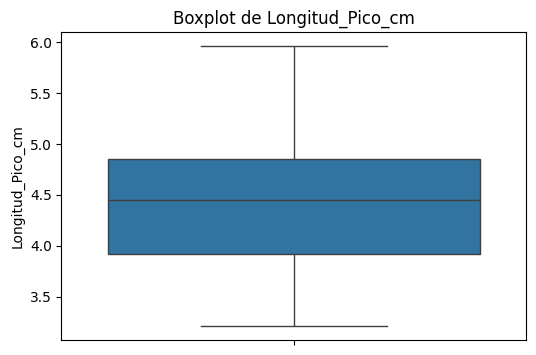

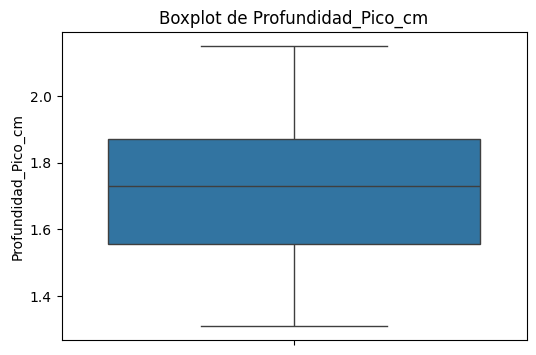

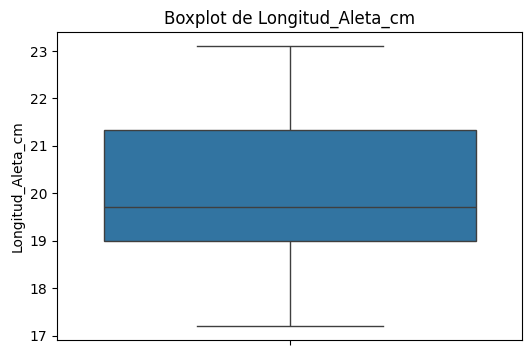

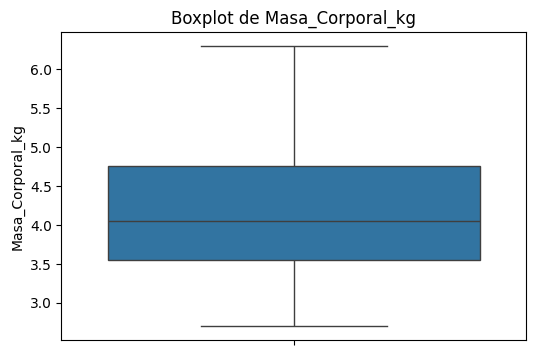

In [65]:
#Boxplot

variables = [
    'Longitud_Pico_cm',
    'Profundidad_Pico_cm',
    'Longitud_Aleta_cm',
    'Masa_Corporal_kg'
]

for var in variables:
    plt.figure(figsize=(6,4))
    sns.boxplot(y=pinwinos[var])
    plt.title(f'Boxplot de {var}')
    plt.show()

Los boxplots de las variables analizadas se muestran sin observaciones extremas claramente separadas del resto de los datos. No se identifican valores atípicos relevantes en ninguna de las variables consideradas, ya que no se observan puntos fuera de los límites definidos por los bigotes de los diagramas.

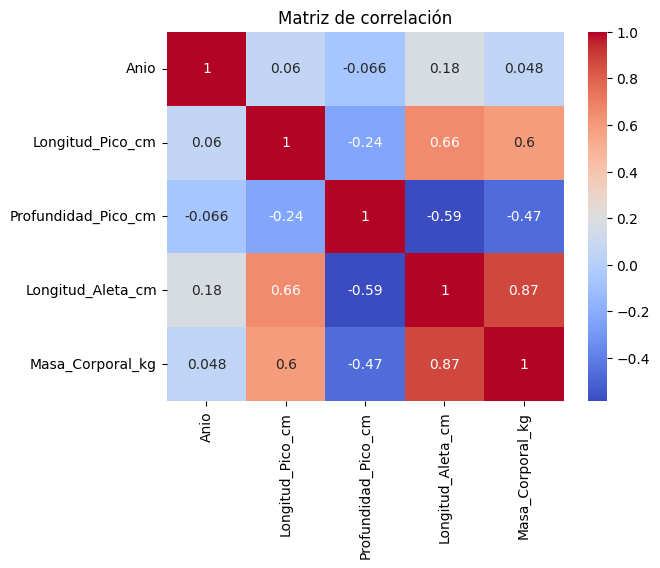

In [66]:
#Matriz de correlaciones entre variables numéricas
corr = pinwinos.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Matriz de correlación")
plt.show()

La matriz de correlación permite analizar la relación lineal entre las variables numéricas del conjunto de datos de los pingüinos.

Podemos observar una correlación positiva muy fuerte entre la longitud de la aleta y la masa corporal (0.87), lo que indica que los pingüinos con aletas más largas tienden a tener mayor peso. También se encuentran correlaciones positivas moderadas entre la longitud del pico y la longitud de la aleta (0.66), así como entre la longitud del pico y la masa corporal (0.60), lo que sugiere que los individuos de mayor tamaño presentan mayores dimensiones en estas variables.

Por otro lado, la profundidad del pico muestra correlaciones negativas con la longitud de la aleta (-0.59) y con la masa corporal (-0.47), lo que indica una tendencia a que individuos con picos más profundos presenten menor tamaño corporal en comparación.

Por lo tanto, los resultados muestran que las variables relacionadas con el tamaño corporal están fuertemente asociadas entre sí, mientras que la profundidad del pico presenta un comportamiento inverso respecto a estas medidas.

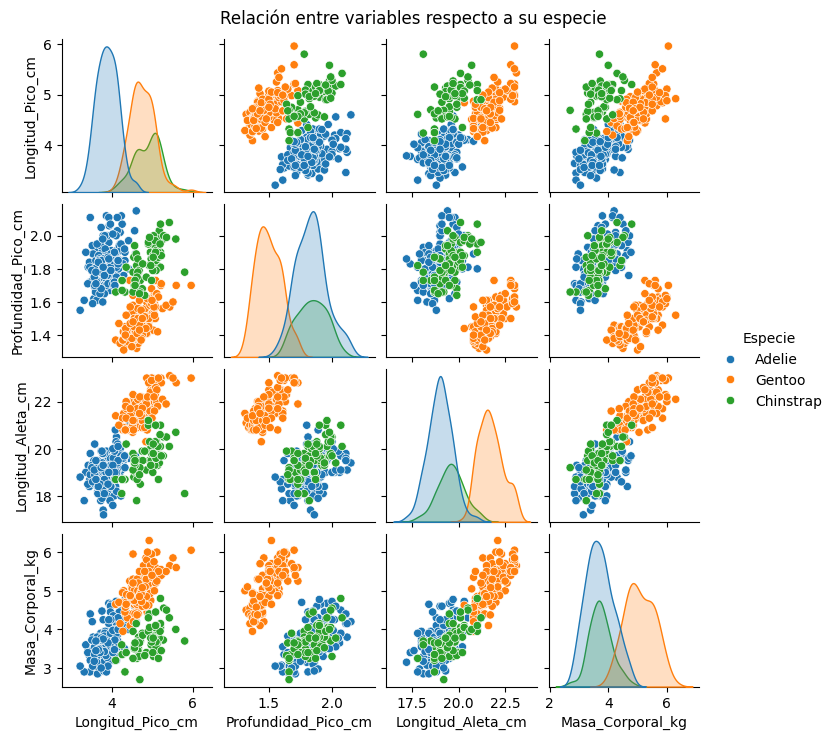

In [67]:
#Grafico de concentración de tipo de respuesta
r = sns.pairplot(variablesnum, hue="Especie", height=1.8, aspect=1)
r.fig.suptitle("Relación entre variables respecto a su especie", y=1.02)
plt.show()

La gráfica muestra una matriz de dispersión de las variables morfológicas de los pingüinos clasificadas por especie. Podemos observar que las tres especies presentan patrones que se pueden diferenciar entre varias combinaciones de variables.

Como podemos observar, los pingüinos Gentoo son los que cuentan con mayor masa corporal y las aletas más largas del conjunto de datos. En la gráfica forman un grupo relativamente separado de las demás especies, lo que indica que estas variables son especialmente útiles para identificarlos.

Por su parte, los pingüinos Adelie suelen tener una menor masa corporal y una menor longitud de aleta. Sin embargo, se caracterizan por presentar picos más profundos, rasgo que permite distinguirlos de las otras especies.

Los pingüinos Chinstrap muestran características intermedias entre Adelie y Gentoo. Aunque su masa corporal es similar a la de los Adelie, suelen presentar una mayor longitud de pico, lo que facilita su diferenciación.

En general, el análisis exploratorio muestra que las especies presentan características morfológicas diferenciadas, aunque con cierto grado de superposición entre algunas observaciones. Estas diferencias permiten comprender mejor la composición del conjunto de datos.